# Day 13 Tutorial：公平比较五个传统模型

## Goal

让 Dummy、Ridge、决策树、随机森林和梯度提升在同一人工数据、同一组 5 折和同一指标下比较，保留逐折与汇总证据。


## Setup

本 Notebook 只接受课程 Day 13 目录或 `experiments/day13_fair_comparison/` 个人目录。课程源写入 `tutorial_outputs/`；个人副本只写自己的 `results/`。如果运行目录无法安全识别，第一格会停止并给出可执行提示，不会猜测输出位置。


In [1]:
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_regression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_SEED = 42
N_SPLITS = 5

def find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "requirements-learning.txt").is_file():
            return candidate
    raise FileNotFoundError("Could not locate repository root")

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = find_repo_root(CURRENT_DIR)
COURSE_DIR = REPO_ROOT / "curriculum/core/day13_fair_comparison"
LEARNER_DIR = REPO_ROOT / "experiments/day13_fair_comparison"

def repo_relative(path):
    return path.resolve().relative_to(REPO_ROOT).as_posix()

if CURRENT_DIR == COURSE_DIR:
    RUN_MODE = "course_tutorial"
    OUTPUT_DIR = COURSE_DIR / "tutorial_outputs"
elif CURRENT_DIR == LEARNER_DIR:
    RUN_MODE = "learner_workspace"
    OUTPUT_DIR = LEARNER_DIR / "results"
else:
    raise RuntimeError(
        "无法安全判断 Day 13 输出目录。请在以下二选一目录中启动或执行 Notebook：\n"
        "- curriculum/core/day13_fair_comparison\n"
        "- experiments/day13_fair_comparison\n"
        "若个人目录还不存在，先在仓库根目录运行：python scripts/start_day.py 13"
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print({
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "mode": RUN_MODE,
    "output": repo_relative(OUTPUT_DIR),
})


{'python': '3.10.20', 'sklearn': '1.7.2', 'mode': 'course_tutorial', 'output': 'curriculum/core/day13_fair_comparison/tutorial_outputs'}


## Steps

### 1. 创建固定人工数据和完全相同的折


In [2]:
X, y = make_regression(
    n_samples=120, n_features=8, n_informative=6, noise=15.0, random_state=RANDOM_SEED
)
y = y + 18.0 * np.sin(X[:, 0])  # 添加可复现的轻微非线性
X[[4, 18, 39, 67, 91, 113], [0, 2, 5, 1, 7, 3]] = np.nan

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
cv_splits = list(cv.split(X))
print({"X": X.shape, "y": y.shape, "folds": len(cv_splits), "missing": int(np.isnan(X).sum())})


{'X': (120, 8), 'y': (120,), 'folds': 5, 'missing': 6}


### 2. 声明固定基线与统一指标

Ridge 需要缩放；树模型不缩放。所有会学习的预处理都留在各自 Pipeline 内。


In [3]:
models = {
    "dummy": make_pipeline(
        SimpleImputer(strategy="median"), DummyRegressor(strategy="mean")
    ),
    "ridge": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0)
    ),
    "decision_tree": make_pipeline(
        SimpleImputer(strategy="median"),
        DecisionTreeRegressor(max_depth=4, random_state=RANDOM_SEED),
    ),
    "random_forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestRegressor(
            n_estimators=60, min_samples_leaf=2, max_features="sqrt",
            random_state=RANDOM_SEED, n_jobs=1,
        ),
    ),
    "gradient_boosting": make_pipeline(
        SimpleImputer(strategy="median"),
        GradientBoostingRegressor(
            n_estimators=60, learning_rate=0.08, max_depth=2, random_state=RANDOM_SEED
        ),
    ),
}
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}
print("Models:", list(models))


Models: ['dummy', 'ridge', 'decision_tree', 'random_forest', 'gradient_boosting']


### 3. 展开为逐模型、逐折长表


In [4]:
fold_rows = []
for model_name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=cv_splits, scoring=scoring, return_train_score=False, n_jobs=1
    )
    for fold_index in range(N_SPLITS):
        fold_rows.append({
            "model": model_name,
            "fold": fold_index + 1,
            "split": "cv_valid",
            "mae": float(-scores["test_mae"][fold_index]),
            "rmse": float(-scores["test_rmse"][fold_index]),
            "r2": float(scores["test_r2"][fold_index]),
            "fit_seconds": float(scores["fit_time"][fold_index]),
        })

fold_metrics = pd.DataFrame(fold_rows)
preview_columns = ["model", "fold", "split", "mae", "rmse", "r2"]
display(fold_metrics.loc[:, preview_columns].head(10).round(4))


,model,fold,split,mae,rmse,r2
0,dummy,1,cv_valid,99.9577,123.3705,-0.2201
1,dummy,2,cv_valid,92.0413,115.3721,-0.0001
2,dummy,3,cv_valid,131.8765,155.9449,-0.0312
3,dummy,4,cv_valid,122.0917,158.1096,-0.0765
4,dummy,5,cv_valid,125.0139,167.4333,-0.0093
5,ridge,1,cv_valid,15.7021,20.1059,0.9676
6,ridge,2,cv_valid,15.9555,20.1007,0.9696
7,ridge,3,cv_valid,15.1013,20.0943,0.9829
8,ridge,4,cv_valid,16.2074,18.9067,0.9846
9,ridge,5,cv_valid,11.6675,13.8367,0.9931


### 4. 汇总并保存实际教程输出


,model,mae_mean,rmse_mean,rmse_std,rmse_min,rmse_max,r2_mean,n_folds
0,ridge,14.9268,18.6088,2.7173,13.8367,20.1059,0.9796,5
1,gradient_boosting,58.2607,75.1281,13.2315,56.4516,89.3934,0.7085,5
2,random_forest,68.5626,91.5439,14.4172,69.6407,107.6899,0.5454,5
3,decision_tree,92.5809,116.6940,18.4090,97.1048,141.1643,0.2929,5
4,dummy,114.1962,144.0461,23.1084,115.3721,167.4333,-0.0674,5


Saved: curriculum/core/day13_fair_comparison/tutorial_outputs/fold_metrics.csv curriculum/core/day13_fair_comparison/tutorial_outputs/model_summary.csv


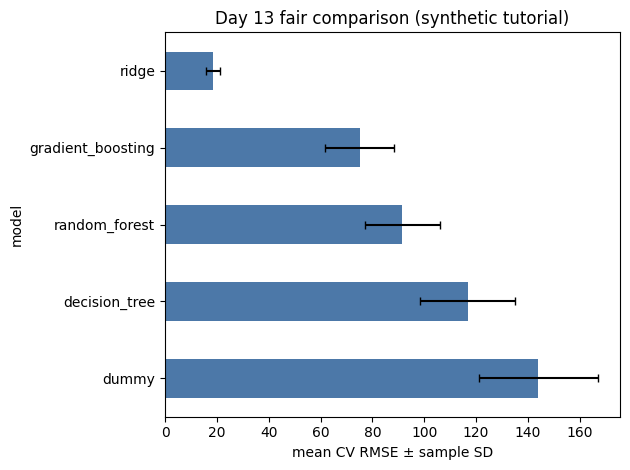

In [5]:
fold_path = OUTPUT_DIR / "fold_metrics.csv"
summary_path = OUTPUT_DIR / "model_summary.csv"
artifact_columns = ["model", "fold", "split", "mae", "rmse", "r2"]
artifact_fold_metrics = fold_metrics.loc[:, artifact_columns].copy()

model_summary = (
    artifact_fold_metrics.groupby("model")
    .agg(
        mae_mean=("mae", "mean"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        rmse_min=("rmse", "min"),
        rmse_max=("rmse", "max"),
        r2_mean=("r2", "mean"),
        n_folds=("fold", "count"),
    )
    .reset_index()
    .sort_values("rmse_mean")
    .reset_index(drop=True)
)
artifact_fold_metrics.to_csv(fold_path, index=False)
model_summary.to_csv(summary_path, index=False)

display(model_summary.round(4))
print("Saved:", repo_relative(fold_path), repo_relative(summary_path))
# fit_seconds 仅保留在运行时内存变量中，不进入预存展示或 CSV fixture。

ax = model_summary.plot.barh(
    x="model", y="rmse_mean", xerr="rmse_std", legend=False, color="#4C78A8", capsize=3
)
ax.invert_yaxis()
ax.set(title="Day 13 fair comparison (synthetic tutorial)", xlabel="mean CV RMSE ± sample SD")
plt.tight_layout()
plt.show()


## Checks

检查模型×折完整性、重复、划分名称、数值以及实际输出文件。


In [6]:
expected_rows = len(models) * N_SPLITS
assert len(fold_metrics) == expected_rows
assert not fold_metrics.duplicated(["model", "fold"]).any()
assert set(fold_metrics["split"]) == {"cv_valid"}
assert (fold_metrics.groupby("model")["fold"].nunique() == N_SPLITS).all()
assert set(fold_metrics["model"]) == set(models)
assert np.isfinite(fold_metrics[["mae", "rmse", "r2", "fit_seconds"]]).all().all()
assert np.isfinite(artifact_fold_metrics[["mae", "rmse", "r2"]]).all().all()
assert list(artifact_fold_metrics.columns) == ["model", "fold", "split", "mae", "rmse", "r2"]
assert (fold_metrics["rmse"] >= fold_metrics["mae"] - 1e-12).all()
assert fold_path.is_file() and summary_path.is_file()

print(f"Checks passed: {expected_rows} complete model-fold rows.")


Checks passed: 25 complete model-fold rows.


## Next Steps

先完成练习并阅读逐折表，不只看排序。课程源输出只是 `deterministic_synthetic_tutorial` fixture；个人副本会自动把本人运行的 CSV 写到 `experiments/day13_fair_comparison/results/`。若换成 ESOL，必须重新记录 ECFP、允许的数据区域和折方式，普通随机 KFold 不能改称 scaffold 验证。
